# ISL Chapter 2: Statistical Learning — Exercises

Scaffold for the applied and selected conceptual exercises. The instructions are **paraphrased in my own words** — check the ISLP text for the exact wording and any equations referenced by number. Code cells are left blank for you to fill in.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from ISLP import load_data


### Exercise 8 — College data set

Explore the `College` data (777 US colleges) from `College.csv`.

**(a)** Read `College.csv` with `pd.read_csv` into a variable called `college`. Make sure the working directory points at the file.

In [3]:
# (a)
college = pd.read_csv('./data/College.csv')

**(b)** The first column is the (unnamed) college name — you don't want pandas treating it as data, but it's handy as a row label. Reload using the name column as the index:

In [4]:
# (b)
college2 = pd.read_csv('./data/College.csv', index_col=0)
college3 = college.rename({'Unnamed: 0': 'College'}, axis=1)
college3 = college3.set_index('College')
college = college3

**(c)** Produce a numerical summary of the variables with `college.describe()`.

In [5]:
# (c)
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


**(d)** Make a scatterplot matrix of the first columns `[Top10perc, Apps, Enroll]` using `pd.plotting.scatter_matrix`.

array([[<Axes: xlabel='Top10perc', ylabel='Top10perc'>,
        <Axes: xlabel='Apps', ylabel='Top10perc'>,
        <Axes: xlabel='Enroll', ylabel='Top10perc'>],
       [<Axes: xlabel='Top10perc', ylabel='Apps'>,
        <Axes: xlabel='Apps', ylabel='Apps'>,
        <Axes: xlabel='Enroll', ylabel='Apps'>],
       [<Axes: xlabel='Top10perc', ylabel='Enroll'>,
        <Axes: xlabel='Apps', ylabel='Enroll'>,
        <Axes: xlabel='Enroll', ylabel='Enroll'>]], dtype=object)

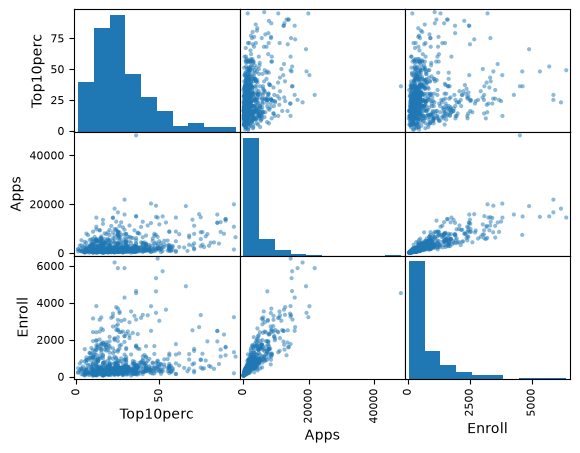

In [6]:
# (d)
pd.plotting.scatter_matrix(college[["Top10perc", "Apps", "Enroll"]])

**(e)** Side-by-side boxplots of `Outstate` grouped by `Private`.

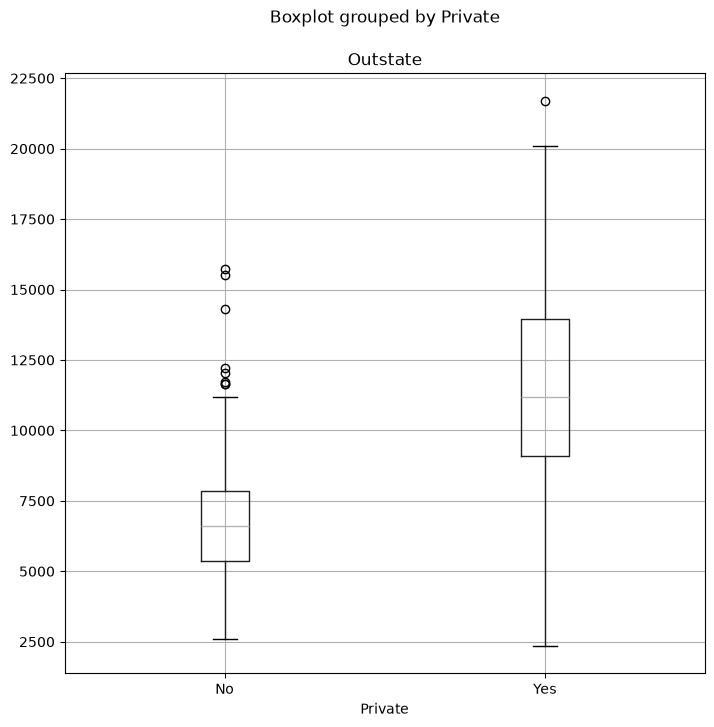

In [7]:
# (e)
fig, ax = subplots(figsize=(8, 8))
college.boxplot('Outstate', by='Private', ax=ax);

**(f)** Create a qualitative variable `Elite` by binning `Top10perc` (elite = more than half the incoming class from the top 10% of their HS class). Count the elite colleges with `value_counts`, then boxplot `Outstate` by `Elite`.

In [8]:
# (f)
# note: Top10perc is on a 0-100 scale, so the bin edges [0, 0.5, 1] shown in the
# book/PDF put nearly every row into one bin. You almost certainly want [0, 50, 100].
college['Elite'] = pd.cut(college['Top10perc'], [0, 50, 100], labels=['No', 'Yes'])

**(g)** Histograms (with differing bin counts) for a few quantitative variables. `plt.subplots(2, 2)` splits the figure into four panels.

(array([ 1.,  0.,  2.,  0.,  0.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,
         0.,  1.,  0.,  0.,  1.,  1.,  0.,  0.,  0.,  2.,  0.,  1.,  1.,
         2.,  1.,  3.,  4.,  2.,  0.,  4.,  2.,  1.,  4.,  4.,  5.,  5.,
         0.,  6.,  2., 12.,  5.,  4.,  8.,  6., 12.,  4.,  8., 10., 14.,
        11.,  8., 11., 11., 19., 15.,  8.,  0., 11., 13., 17., 15., 11.,
        11., 21., 12., 24., 18., 21., 20., 26., 18., 19., 19., 21., 21.,
        11.,  0., 17., 15., 15., 18., 18., 20., 23., 17., 12., 17., 10.,
        16.,  8.,  7.,  2.,  6.,  3.,  0.,  0.,  1.]),
 array([  8.  ,   8.95,   9.9 ,  10.85,  11.8 ,  12.75,  13.7 ,  14.65,
         15.6 ,  16.55,  17.5 ,  18.45,  19.4 ,  20.35,  21.3 ,  22.25,
         23.2 ,  24.15,  25.1 ,  26.05,  27.  ,  27.95,  28.9 ,  29.85,
         30.8 ,  31.75,  32.7 ,  33.65,  34.6 ,  35.55,  36.5 ,  37.45,
         38.4 ,  39.35,  40.3 ,  41.25,  42.2 ,  43.15,  44.1 ,  45.05,
         46.  ,  46.95,  47.9 ,  48.85,  49.8 ,  50.75,  51.7 ,  52.65,
  

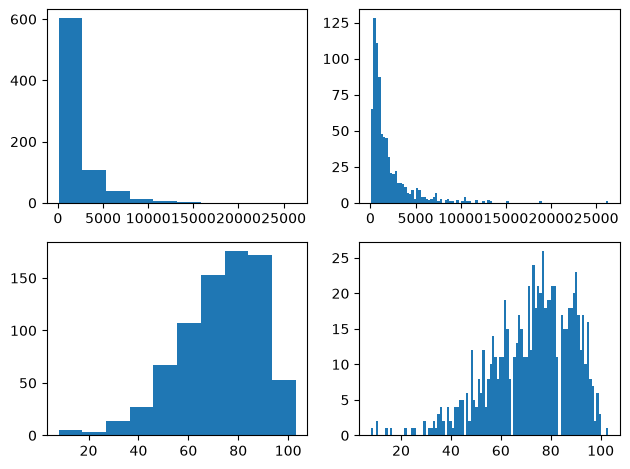

In [9]:
# (g)
fig, axs = plt.subplots(2, 2, tight_layout=True)

axs[0,0].hist(college['Accept'], bins=10)
axs[0,1].hist(college['Accept'], bins=100)
axs[1,0].hist(college['PhD'], bins=10)
axs[1,1].hist(college['PhD'], bins=100)

**(h)** Keep exploring and write a brief summary of what you find.

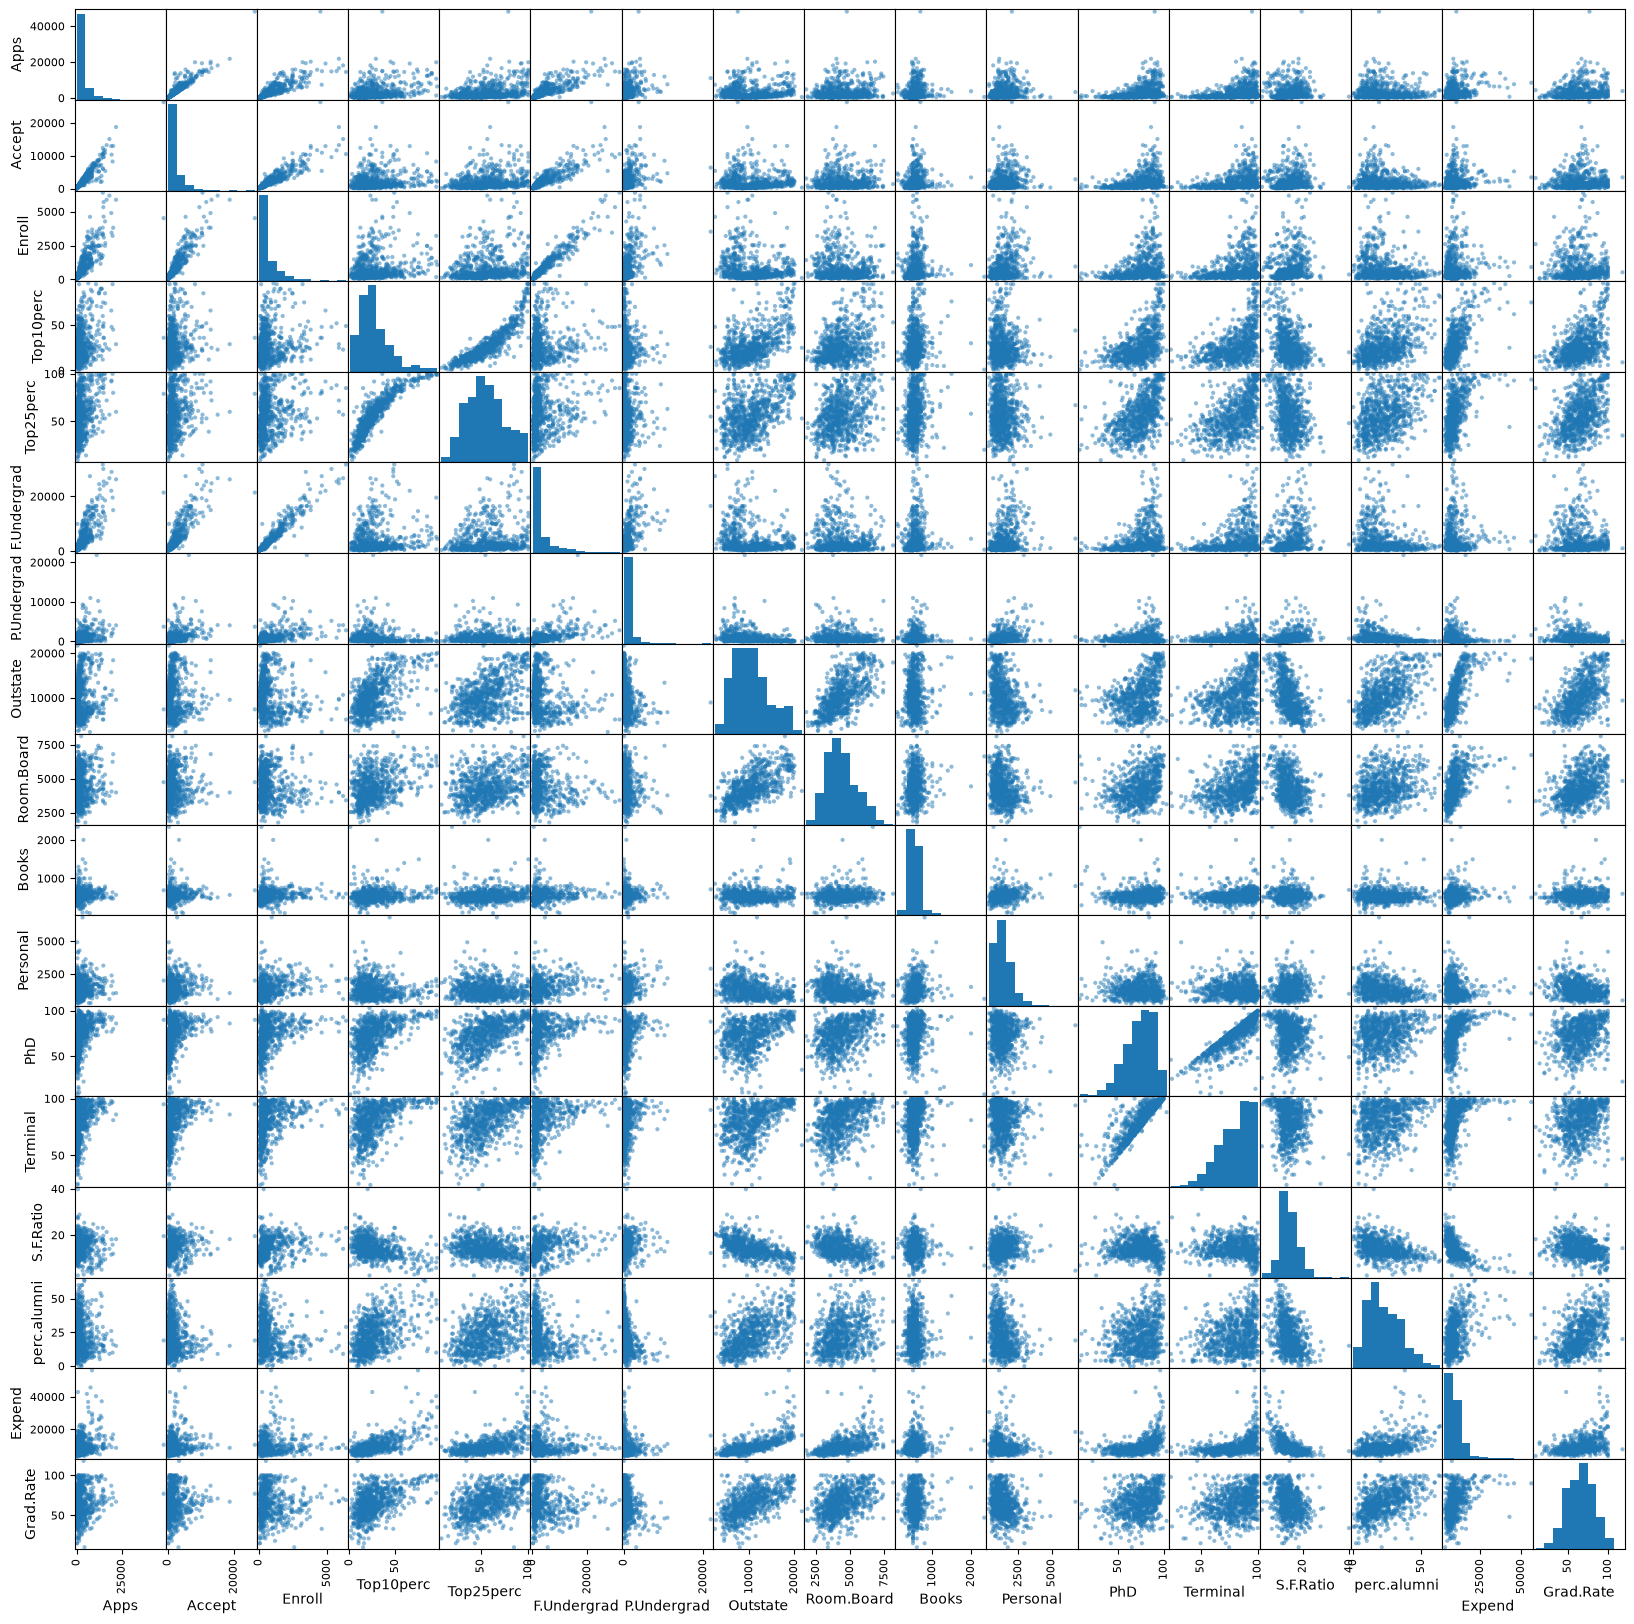

In [10]:
# (h)
pd.plotting.scatter_matrix(college, figsize=(20,20));

### Exercise 9 — Auto data set

Use the `Auto` data (make sure missing values are dropped first).

**(a)** Which predictors are quantitative and which are qualitative?

In [11]:
# (a)
Auto = pd.read_csv('./data/Auto.data',
                   na_values=['?'],
                   delim_whitespace=True)
Auto.describe()

/tmp/ipykernel_2979770/4262328325.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  Auto = pd.read_csv('./data/Auto.data',


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,397.000000,397.000000,397.000000,392.000000,397.000000,397.000000,397.000000,397.000000
mean,23.515869,5.458438,193.532746,104.469388,2970.261965,15.555668,75.994962,1.574307
std,7.825804,1.701577,104.379583,38.491160,847.904119,2.749995,3.690005,0.802549
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.000000,75.000000,2223.000000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,146.000000,93.500000,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3609.000000,17.100000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


**(b)** Range (min and max) of each quantitative predictor.

In [12]:
# (b)
print(Auto.max(numeric_only=True))
print(Auto.min(numeric_only=True))

mpg               46.6
cylinders          8.0
displacement     455.0
horsepower       230.0
weight          5140.0
acceleration      24.8
year              82.0
origin             3.0
dtype: float64
mpg                9.0
cylinders          3.0
displacement      68.0
horsepower        46.0
weight          1613.0
acceleration       8.0
year              70.0
origin             1.0
dtype: float64


**(c)** Mean and standard deviation of each quantitative predictor.

In [13]:
# (c)
print(Auto.std(numeric_only=True))
print(Auto.mean(numeric_only=True))

mpg               7.825804
cylinders         1.701577
displacement    104.379583
horsepower       38.491160
weight          847.904119
acceleration      2.749995
year              3.690005
origin            0.802549
dtype: float64
mpg               23.515869
cylinders          5.458438
displacement     193.532746
horsepower       104.469388
weight          2970.261965
acceleration      15.555668
year              75.994962
origin             1.574307
dtype: float64


**(d)** Remove observations 10 through 85, then report the range, mean, and sd of each predictor in what remains.

In [14]:
# (d)
temp_Auto = pd.concat([Auto[:10], Auto[85:]])
print(temp_Auto.max(numeric_only=True))
print(temp_Auto.min(numeric_only=True))
print(temp_Auto.std(numeric_only=True))
print(temp_Auto.mean(numeric_only=True))

mpg               46.6
cylinders          8.0
displacement     455.0
horsepower       230.0
weight          4997.0
acceleration      24.8
year              82.0
origin             3.0
dtype: float64
mpg               11.0
cylinders          3.0
displacement      68.0
horsepower        46.0
weight          1649.0
acceleration       8.5
year              70.0
origin             1.0
dtype: float64
mpg               7.913357
cylinders         1.657398
displacement    100.120925
horsepower       36.185088
weight          810.987533
acceleration      2.706436
year              3.131849
origin            0.815572
dtype: float64
mpg               24.409317
cylinders          5.378882
displacement     187.680124
horsepower       101.235849
weight          2936.807453
acceleration      15.700621
year              77.130435
origin             1.596273
dtype: float64


**(e)** Investigate the predictors graphically (scatterplots etc.); highlight relationships and comment.

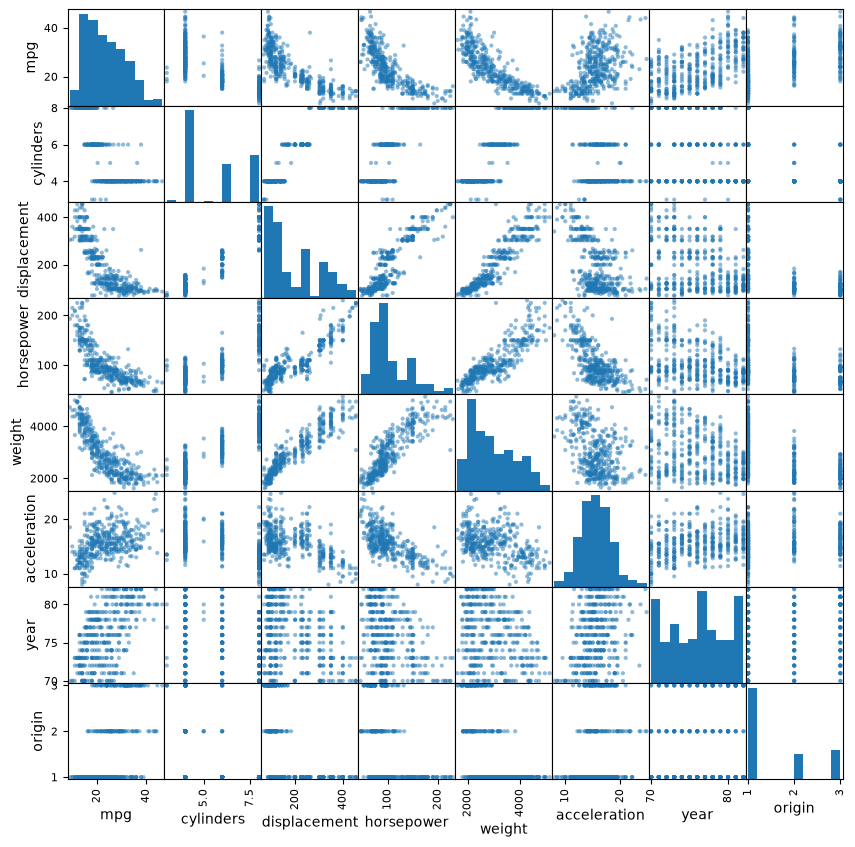

In [15]:
# (e)
pd.plotting.scatter_matrix(Auto, figsize=(10,10));

**(f)** Which variables look useful for predicting `mpg`? Justify from your plots.

Displacement or horsepower would work best as we see it in plots above.

### Exercise 10 — Boston data set

Work with the `Boston` housing data (in the ISLP library).

**(a)** Load `Boston` from ISLP.

In [16]:
# (a)
boston_data = pd.read_csv('./data/Boston.csv')
boston_data = boston_data.rename({'Unnamed: 0': 'SuburbID'}, axis=1)
boston_data = boston_data.set_index('SuburbID')


**(b)** How many rows and columns? What do rows and columns represent?


In [17]:
# (b)
print("Number of rows: ", boston_data.shape[0], "\nNumber of columns: ", boston_data.shape[1])

Number of rows:  506 
Number of columns:  13


**(c)** Pairwise scatterplots of the predictors; describe findings.


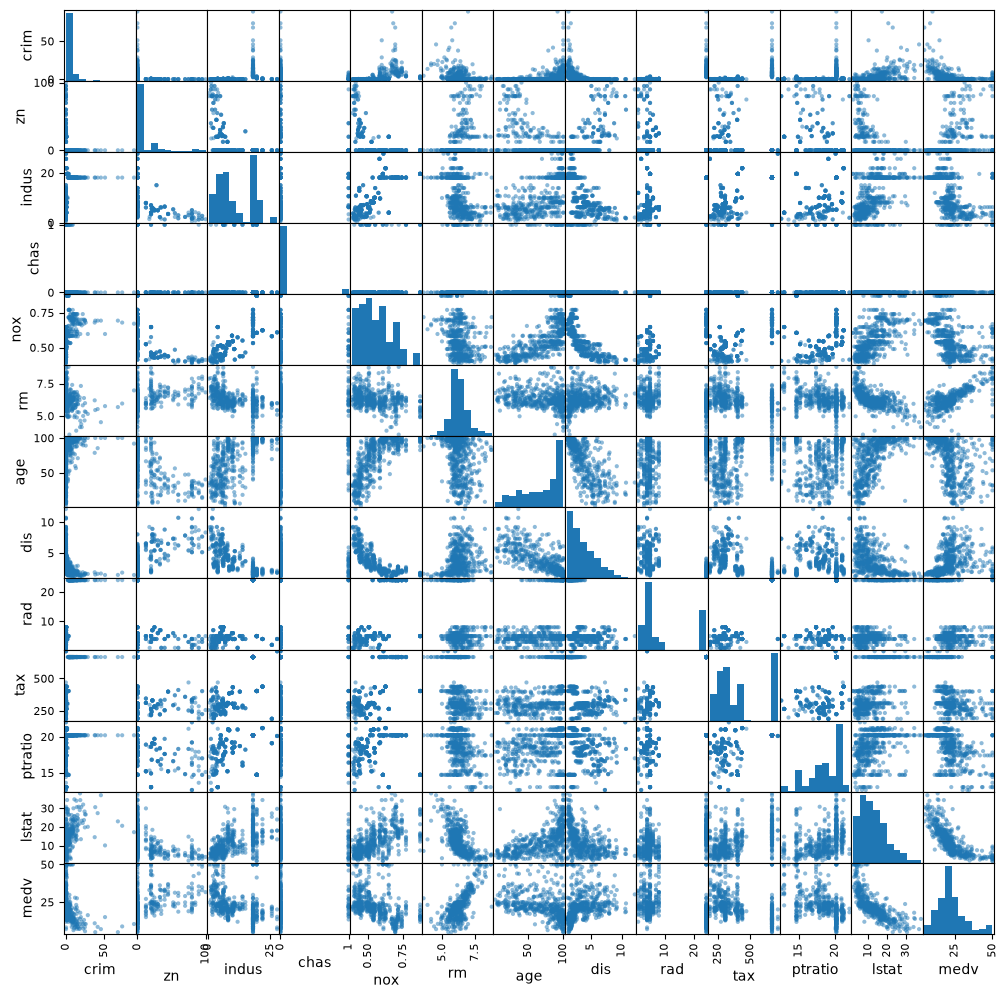

In [18]:
# (c)
pd.plotting.scatter_matrix(boston_data, figsize=(12,12));
# from this output of matrixes we see that house age and distance are opposite. Not saying that they are simply related or knowing one can help us predict another.  

**(d)** Are any predictors associated with per-capita crime rate? Explain.


In [19]:
# (d)
# from the scatter matrix above it seeme zn will be a goo predictor for per-capita crime rate. 

**(e)** Any suburbs with especially high crime / tax / pupil-teacher ratios? Comment on each range.


In [20]:
# (e)
print(boston_data.max(numeric_only=True))
print(boston_data.min(numeric_only=True))
print("top crime rates: ", boston_data.nlargest(10, 'crim').index.tolist())
print("top tax rates: ", boston_data.nlargest(10, 'tax').index.tolist())
print("top pupil rates: ", boston_data.nlargest(10, 'ptratio').index.tolist())


crim        88.9762
zn         100.0000
indus       27.7400
chas         1.0000
nox          0.8710
rm           8.7800
age        100.0000
dis         12.1265
rad         24.0000
tax        711.0000
ptratio     22.0000
lstat       37.9700
medv        50.0000
dtype: float64
crim         0.00632
zn           0.00000
indus        0.46000
chas         0.00000
nox          0.38500
rm           3.56100
age          2.90000
dis          1.12960
rad          1.00000
tax        187.00000
ptratio     12.60000
lstat        1.73000
medv         5.00000
dtype: float64
top crime rates:  [381, 419, 406, 411, 415, 405, 399, 428, 414, 418]
top tax rates:  [489, 490, 491, 492, 493, 357, 358, 359, 360, 361]
top pupil rates:  [355, 356, 128, 129, 130, 131, 132, 133, 134, 135]


**(f)** How many suburbs bound the Charles river?


In [21]:
# (f)
print("Number of suburbs bound to charles river", boston_data[boston_data["chas"]==1].shape[0])

Number of suburbs bound to charles river 35


**(g)** Median pupil-teacher ratio across towns.


In [22]:
# (g)
print("Median pupil=teacher ratio accross towns", boston_data.median(numeric_only=True)['ptratio'])

Median pupil=teacher ratio accross towns 19.05


**(h)** Which suburb has the lowest median home value? Compare its other predictors to the overall ranges.


In [23]:
# (h)
print("Suburb with lowest median home value: ", boston_data.nsmallest(1, 'medv').index.tolist()[0])
print("Data of the suburb with lowest median home value: ")
boston_data.nsmallest(1, 'medv')
# Tax is high so is crime and the median value of home is low.

Suburb with lowest median home value:  399
Data of the suburb with lowest median home value: 


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
SuburbID,,,,,,,,,,,,,
399,38.3518,0.0,18.1,0,0.693,5.453,100.0,1.4896,24,666,20.2,30.59,5.0


**(i)** How many suburbs average more than 7 rooms per dwelling? More than 8? Comment on the >8 group.

In [24]:
# (i)
print("Number of suburbs with more than 7 rooms on average", boston_data[boston_data["rm"]>6].shape[0])

Number of suburbs with more than 7 rooms on average 333
